#**Individual Hypertension Risk Prediction**

#**Import Library**



In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#**Memuat Dataset**

In [3]:
file = "/content/drive/MyDrive/CheckPoint AVD/hypertension_dataset.csv"

df = pd.read_csv(file)

df

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No
...,...,...,...,...,...,...,...,...,...,...,...
1980,56,10.2,0,Normal,6.5,25.0,Diuretic,Yes,Low,Non-Smoker,Yes
1981,29,8.9,4,Hypertension,6.9,16.9,NaN,Yes,High,Non-Smoker,Yes
1982,64,5.9,9,Normal,5.6,18.9,ACE Inhibitor,Yes,Moderate,Non-Smoker,Yes
1983,35,7.4,8,Prehypertension,8.2,29.2,NaN,Yes,Moderate,Non-Smoker,No


#**Bussiness Understanding**

##**Bussiness Objective**

Dataset *Hypertension Risk Prediction* merupakan dataset kesehatan yang digunakan untuk menganalisis dan memprediksi risiko hipertensi pada individu berdasarkan berbagai faktor yang mempengaruhinya. Dataset ini diperoleh dari Kaggle yang merupakan platform penyedia dataset.

Tujuan utama dari analisis ini adalah untuk membantu tenaga kesehatan, instansi kesehatan, maupun program kesehatan masyarakat dalam mengidentifikasi individu yang memiliki risiko hipertensi sejak dini. Dengan adanya sistem prediksi berbasis data, proses *screening* kesehatan dapat dilakukan secara lebih cepat dan efisien dibandingkan metode konvensional.

Selain itu, analisis ini bertujuan untuk mendukung program pencegahan penyakit dengan memberikan informasi mengenai faktor-faktor yang berpengaruh terhadap risiko hipertensi. Dalam jangka panjang, hasil analisis ini diharapkan dapat mengurangi angka penderita hipertensi.



##**Asses Situation**

Dalam dataset yang digunakan sudah mencakup beberapa faktor penting seperti usia, jenis kelamin, kebiasaan merokok, aktivitas fisik, serta indikator kesehatan lainnya. Hal ini menunjukkan bahwa dataset memiliki potensi yang baik untuk digunakan dalam proses analisis dan pembuatan model prediksi.

Namun, terdapat beberapa tantangan yang mungkin muncul, seperti adanya data kosong atau *missing value*. Selain itu, karena data berkaitan dengan kesehatan, hasil analisis harus diartikan secara hati-hati agar tidak menimbulkan kesalahan pengambilan keputusan medis.

##**Analytic Goals & Project Plan**


Tujuan analitik dari analisis dataset *Hypertension Risk Prediction* dapat dicapai dengan melakukan beberapa tahapan analisis dan pengolahan data sebagai berikut:
1. Menganalisa hubungan antara faktor kesehatan dengan gaya hidup pada risiko hipertensi.
2. Mengidentifikasi risiko hipertensi untuk pencegahan di kalangan umum.
3. Melakukan perbandingan kondisi kesehatan antara individu yang mengalami hipertensi dan tidak mengalami hipertensi.
4. Menghasilkan informasi yang dapat digunakan sebagai dasar edukasi kesehatan dan peningkatan kesadaran terhadap hipertensi.
5. Mendukung pengambilan keputusan dalam program pencegahan dan promosi kesehatan berbasis data.

#**Data Understanding**

##**Struktur Data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   object 
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   object 
 7   Family_History    1985 non-null   object 
 8   Exercise_Level    1985 non-null   object 
 9   Smoking_Status    1985 non-null   object 
 10  Has_Hypertension  1985 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 170.7+ KB


Berdasarkan data diatas dapat disimpulkan bahwa dataset ini memiliki 1985 baris dan 11 kolom, yang terdiri dari:

1. Age: Jumlah baris 1985, tipe data int64, deskripsi: Umur
2. Salt_Intake: Jumlah baris 1985, tipe data float64, deskripsi: asupan garam yang dikonsumsi.
3. Stress_Score: Jumlah baris 1985, tipe data int64, deskripsi: Skor atau nilai stress.
4. Bp_History: Jumlah baris 1985, tipe data object, deskripsi: Kondisi tekanan darah.
5. Sleep_Duration: Jumlah baris 1985, tipe data float64, deskripsi: Durasi tidur.
6. BMI: Jumlah baris 1985, tipe data float64, deskripsi: Indeks masa tubuh untuk menentukan kategori berat badan seorang.
7. Medication: Jumlah baris 1985, tipe data object, deskripsi: jenis obat yang dikonsumsi kepada pasien.
8. Family_History: Jumlah baris 1985, tipe data object, deskripsi: Riwayat penyakit dari keluarga.
9.  Exercise_Level: Jumlah baris 1985, tipe data object, deskripsi: level aktivitas fisik.
10. Smoking_Status: Jumlah baris 1985, tipe data object, deskripsi: kebiasaan merokok
11. Has_Hypertension: Jumlah baris 1985, tipe data object, deskripsi: status apakah mengalami hipertensi atau tidak.

##**Statistik Deskriptif**

In [ ]:
df.describe()

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000
mean,50.341058,8.531688,4.979345,6.452242,26.015315
std,19.442042,1.994907,3.142303,1.542207,4.512857
min,18.000000,2.500000,0.000000,1.500000,11.900000
25%,34.000000,7.200000,2.000000,5.400000,23.000000
50%,50.000000,8.500000,5.000000,6.500000,25.900000
75%,67.000000,9.900000,8.000000,7.500000,29.100000
max,84.000000,16.400000,10.000000,11.400000,41.900000


1. Count (Kelengkapan Data)

Berdasarkan data, total observasi adalah **1985 baris**. Maka dapat disimpulkan:

* Age = 1985 (tidak ada missing value)
* Salt_Intake = 1985 (tidak ada missing value)
* Stress_Score = 1985 (tidak ada missing value)
* Sleep_Duration = 1985 (tidak ada missing value)
* BMI = 1985 (tidak ada missing value)

Kesimpulan:Seluruh kolom numerik lengkap (tidak terdapat missing values). Dataset sudah bersih dari sisi kelengkapan data.
2. Mean vs Median (Distribusi Data)

Kolom Age
* Mean = 50,34
* Median = 50,00

Nilai mean dan median hampir sama, distribusi usia relatif simetris dan tidak banyak outlier ekstrem.

Kolom Salt_Intake
* Mean = 8,53
* Median = 8,50

Perbedaan sangat kecil distribusi konsumsi garam cenderung normal/simetris
Kolom Stress_Score
* Mean = 4,98
* Median = 5,00

Mean sedikit lebih kecil dari median distribusi relatif simetris, tidak menunjukkan skewness yang signifikan.

Kolom Sleep_Duration
* Mean = 6,45
* Median = 6,50

Mean sedikit lebih kecil dari median distribusi sedikit left-skewed ringan, namun masih tergolong stabil.

Kolom BMI
* Mean = 26,02
* Median = 25,90

Mean sedikit lebih besar dari median → terdapat kemungkinan beberapa nilai BMI tinggi yang menarik rata-rata ke atas, namun tidak ekstrem.

Kesimpulan Distribusi:
Secara keseluruhan, variabel dalam dataset ini cenderung berdistribusi cukup simetris (mendekati normal) dan tidak menunjukkan skewness yang ekstrem.

3. Min dan Max (Validasi Logika Data)
Age
* Min = 18
* Max = 84

Rentang usia logis untuk populasi dewasa.

Salt_Intake
* Min = 2,5
* Max = 16,4

Rentang konsumsi garam cukup lebar → perlu diperhatikan apakah 16,4 termasuk konsumsi sangat tinggi (berisiko hipertensi).

Stress_Score

* Min = 0
* Max = 10

Skala terlihat seperti skala penilaian (0–10), sehingga valid secara logika.

Sleep_Duration
* Min = 1,5 jam
* Max = 11,4 jam
Durasi tidur minimum 1,5 jam tergolong sangat rendah dan bisa menjadi indikator gangguan tidur atau outlier ringan.

BMI

* Min = 11,9
* Max = 41,9

BMI minimum 11,9 sangat rendah (underweight ekstrem).
BMI maksimum 41,9 menunjukkan kategori obesitas berat.

Kesimpulan:

* Rentang data cukup luas terutama pada BMI dan Salt_Intake.
* Nilai ekstrem (BMI sangat rendah & tinggi, Sleep sangat rendah) perlu dicek apakah valid secara medis atau outlier.

 4. Standar Deviasi (std) – Variabilitas Data
Age
* Mean = 50,34
* Std = 19,44

Variasi usia cukup besar → dataset mencakup rentang generasi yang luas.

Salt_Intake
* Mean = 8,53
* Std = 1,99

Variasi konsumsi garam relatif moderat (sekitar 23% dari mean).

Stress_Score

* Mean = 4,98
* Std = 3,14

Standar deviasi cukup besar dibandingkan mean → tingkat stres antar individu cukup bervariasi.

Sleep_Duration

* Mean = 6,45
* Std = 1,54

Variasi durasi tidur tergolong moderat dan masih dalam batas wajar populasi umum.

BMI
* Mean = 26,02
* Std = 4,51

Standar deviasi sekitar 17% dari mean → variasi BMI cukup signifikan, menunjukkan adanya kelompok underweight hingga obesitas.

Kesimpulan Umum

1. Dataset lengkap tanpa missing values.
2. Sebagian besar variabel berdistribusi cukup simetris.
3. Terdapat beberapa nilai ekstrem pada BMI dan Sleep_Duration yang perlu eksplorasi lebih lanjut.
4. Variabilitas terbesar terlihat pada Age dan Stress_Score, menunjukkan populasi yang heterogen.


## **VERIFIKASI KUALITAS DATA**

###**Data Type Check**

In [ ]:
df.dtypes

,0
Age,int64
Salt_Intake,float64
Stress_Score,int64
BP_History,object
Sleep_Duration,float64
BMI,float64
Medication,object
Family_History,object
Exercise_Level,object
Smoking_Status,object


Terlihat dari data df.types diatas terlihat antara kolom dan tipe data sudah sesuai dan tidak ada yang tidak sesuai.

###**Inconsistent Values**

Pada tahap ini, perlu dilakukan pengecekan konsistensi data, khususnya pada penulisan nilai dalam setiap kolom. Proses ini bertujuan untuk memastikan bahwa data yang secara makna sama tidak tercatat sebagai kategori yang berbeda hanya karena perbedaan format atau penulisan.

1. **Age**

In [ ]:
df['Age'].unique()

array([69, 32, 78, 38, 41, 20, 39, 70, 19, 47, 55, 81, 77, 50, 75, 66, 76,
       59, 79, 64, 68, 72, 24, 56, 35, 21, 31, 26, 61, 25, 52, 53, 67, 23,
       71, 80, 51, 65, 57, 43, 58, 46, 62, 82, 18, 28, 22, 45, 29, 40, 54,
       44, 60, 30, 49, 83, 74, 73, 36, 34, 33, 37, 84, 48, 42, 63, 27])

Terlihat dari data 'Age' di atas bahwa seluruh nilai usia berada pada rentang 18–84 tahun dan semuanya berbentuk angka (integer). Tidak ditemukan nilai negatif atau teks yang tidak sesuai.

Kesimpulan: Data usia sudah konsisten dan tidak terdapat inkonsistensi.

2. **Salt_Intake**

In [ ]:
df['Salt_Intake'].unique()

array([ 8. , 11.7,  9.5, 10. ,  9.8, 10.8,  8.9,  5.9,  9.3,  7.2,  7.4,
        9.7, 11. ,  8.5,  9.1, 11.9,  9. , 13.7,  9.6,  5. , 11.1,  8.2,
        6.1,  8.1,  6.8,  7.3, 11.8,  9.4, 10.9,  6.9,  8.3,  6.7,  7.6,
        9.9,  7.8, 12. ,  7.7, 10.4,  5.7,  5.4, 13.6, 11.6, 12.5, 12.6,
       10.5, 10.1,  8.7, 11.5,  6.2,  7.1,  4.8,  6.5, 12.2,  6.6, 10.7,
       12.3,  7.5,  6.3,  8.8,  5.3,  2.8,  8.4,  9.2, 10.3,  7. ,  3.7,
        7.9,  8.6,  6. ,  5.8,  6.4,  2.7,  3.8, 11.2, 14.9,  5.6, 10.2,
       10.6, 11.3,  4.3, 12.4,  4.2,  3.1, 12.8,  5.5,  4.7,  4.9, 12.1,
        5.2,  5.1, 13. ,  4.5,  3.4, 13.8, 14.8,  2.6,  2.5, 14. ,  3.6,
        3.9, 11.4, 13.3, 12.7,  4.1,  4.6,  3.3, 14.7, 13.2, 14.4, 14.5,
       13.4,  3.2,  4. , 13.9, 12.9,  3. , 16.4,  3.5,  4.4, 13.1, 14.2])

Terlihat bahwa seluruh nilai konsumsi garam berada pada rentang 2.5–16.4 dan berbentuk angka desimal (float). Tidak ditemukan nilai dalam bentuk teks atau format yang berbeda.

Kesimpulan: Data konsumsi garam sudah konsisten dan tidak terdapat inkonsistensi.

3. **Stress_Score**

In [ ]:
df['Stress_Score'].unique()

array([ 9, 10,  3,  1,  0,  7,  5,  8,  6,  4,  2])

Nilai stress score berada pada skala 0–10 dan seluruhnya berbentuk angka (integer). Tidak ada nilai di luar rentang skala maupun format yang berbeda.

Kesimpulan: Data stress score konsisten dan tidak ditemukan inkonsistensi.

4. **BP_History**

In [ ]:
df['BP_History'].unique()

array(['Normal', 'Hypertension', 'Prehypertension'], dtype=object)

Nilai yang muncul hanya terdiri dari 'Normal', 'Hypertension', dan 'Prehypertension' dengan penulisan yang seragam. Tidak ditemukan perbedaan huruf besar-kecil atau typo.

Kesimpulan: Data BP_History konsisten dan tidak mengandung inconsistent value.

5. **Sleep_Duration**

In [ ]:
df['Sleep_Duration'].unique()

array([ 6.4,  5.4,  7.1,  4.2,  5.8,  5.2,  7.8,  7.2,  4.7,  6.2,  5.3,
        7.9,  8.4,  4.3,  7.7,  6.1,  6.5,  9.2,  5. ,  4.6,  2.3,  8.2,
        3.3,  6.3,  8.5,  9.8,  6. ,  4.4,  5.6,  7. ,  5.7,  7.5,  5.9,
        4. ,  6.7,  3.6,  4.5,  3.8,  9.1,  7.6,  9.9,  5.1,  8.8,  6.8,
        8.1,  4.9,  8. ,  3.7,  4.1,  6.6,  9.6,  7.4,  8.9,  9.7,  7.3,
        8.6,  2.2,  3.9,  2.9,  4.8,  3.2,  6.9,  5.5, 10.1,  8.3,  9.4,
        3.5,  8.7,  3. ,  3.4, 10.8, 10.3,  1.6,  9. ,  2. ,  2.5,  9.3,
       10.2, 11. ,  1.5,  2.4,  9.5, 10.6,  2.8,  3.1, 11.4,  1.7, 10. ])

Durasi tidur berada pada rentang 1.5–11.4 jam dan seluruhnya berbentuk angka desimal (float). Tidak ditemukan format teks atau simbol yang tidak sesuai.

Kesimpulan: Format data konsisten dan tidak terdapat inkonsisten.

6. **BMI**

In [ ]:
df['BMI'].unique()

array([25.8, 23.4, 18.7, 22.1, 16.2, 21.9, 27.6, 36.5, 24.3, 24. , 30.8,
       17.3, 19.3, 29. , 25.1, 25.2, 21.8, 27.1, 22.4, 26.3, 20.8, 35.1,
       24.1, 25.4, 26.8, 28.1, 27.2, 27.3, 26.5, 25. , 17.8, 37.8, 29.3,
       21.6, 27. , 19.9, 23.8, 18.9, 27.7, 29.1, 22.3, 26.7, 22. , 28.3,
       22.9, 29.6, 21.5, 21. , 26.9, 28.5, 23.7, 13.4, 26.2, 29.5, 38.1,
       23. , 27.4, 24.8, 31.7, 24.9, 29.9, 31.2, 18.5, 31.8, 26. , 30.1,
       26.4, 20. , 25.9, 32.1, 28.9, 21.4, 24.6, 35.4, 28.7, 23.1, 33.6,
       35.9, 20.2, 22.6, 23.9, 22.8, 33.8, 32.4, 27.8, 25.3, 28.4, 30. ,
       22.5, 20.1, 35.8, 30.9, 25.7, 19.8, 12. , 31.9, 21.3, 28.6, 27.9,
       32.9, 35. , 18.6, 29.2, 41.3, 28. , 26.1, 21.1, 17.5, 31.3, 23.5,
       37.7, 27.5, 18.1, 30.7, 29.4, 20.9, 20.3, 30.6, 23.2, 19.2, 16.1,
       34.3, 23.3, 24.4, 17.4, 28.8, 36.7, 25.5, 33.5, 32.6, 26.6, 17.7,
       21.7, 32.5, 24.2, 20.7, 17.6, 32.8, 33.9, 31.5, 24.5, 32.3, 37.4,
       23.6, 34.2, 19.7, 18.8, 21.2, 29.7, 30.5, 19

Terlihat dari data di atas bahwa nilai BMI berada pada rentang 11.9–41.9 dan seluruhnya berbentuk angka desimal (float). Tidak ditemukan nilai dalam bentuk teks atau format yang berbeda.

Kesimpulan: Secara format data sudah konsisten dan tidak terdapat inkonsistensi.

7. **Medication**

In [ ]:
df['Medication'].unique()

array([nan, 'ACE Inhibitor', 'Other', 'Beta Blocker', 'Diuretic'],
      dtype=object)

Nilai yang muncul terdiri dari 'ACE Inhibitor', 'Beta Blocker', 'Diuretic', 'Other', serta terdapat nilai NaN. Penulisan kategori terlihat konsisten tanpa typo atau perbedaan huruf besar kecil.

Kesimpulan: Tidak terdapat inkonsistensi penulisan, namun terdapat missing value (NaN).

8. **Family_History**

In [ ]:
df['Family_History'].unique()

array(['Yes', 'No'], dtype=object)

Nilai yang muncul hanya 'Yes' dan 'No' dengan penulisan yang seragam. Tidak ditemukan variasi seperti "yes" atau "YES".

Kesimpulan: Data konsisten dan tidak mengandung inconsistent value.

9. **Exercise_Level**

In [ ]:
df['Exercise_Level'].unique()

array(['Low', 'Moderate', 'High'], dtype=object)

Nilai yang muncul terdiri dari 'Low', 'Moderate', dan 'High' dengan format penulisan yang konsisten. Tidak terdapat variasi penulisan atau kategori tambahan.

Kesimpulan: Data sudah konsisten dan tidak ditemukan inkonsistensi.

10. **Smoking_Status**

In [ ]:
df['Smoking_Status'].unique()

array(['Non-Smoker', 'Smoker'], dtype=object)

Nilai yang muncul hanya 'Non-Smoker' dan 'Smoker' dengan penulisan yang seragam. Tidak ditemukan variasi format atau typo.

Kesimpulan: Data konsisten dan tidak terdapat inconsistent value.

11. **Has_Hypertention**

In [ ]:
df['Has_Hypertension'].unique()

array(['Yes', 'No'], dtype=object)

Terlihat dari data di atas bahwa nilai yang muncul hanya 'Yes' dan 'No' dengan penulisan yang seragam. Tidak ditemukan variasi seperti “yes”, “YES”, atau nilai kosong.

Kesimpulan: Data pada kolom Has_Hypertension sudah konsisten dan tidak terdapat inconsistent value.

###**Missing Values**

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Age,0.000000
Salt_Intake,0.000000
Stress_Score,0.000000
BP_History,0.000000
Sleep_Duration,0.000000
BMI,0.000000
Medication,40.251889
Family_History,0.000000
Exercise_Level,0.000000
Smoking_Status,0.000000


Terlihat dari data diatas, kesimoulannya adalah:

1. Age Null 0%
Tidak terdapat missing value, data lengkap dan siap digunakan.

2. Salt_Intake Null 0%
Tidak terdapat missing value.

3. Stress_Score Null 0%
Data lengkap tanpa nilai kosong.

4. BP_History Null 0%
Tidak ditemukan missing value.

5. Sleep_Duration Null 0%
Data lengkap dan konsisten.

6. BMI Null 0%
Tidak terdapat missing value.

7. Medication Null 40.25%
Terdapat missing value dalam jumlah cukup besar, perlu penanganan khusus pada tahap preprocessing.

8. Family_History Null 0%
Data lengkap tanpa nilai kosong.

9. Exercise_Level Null 0%
Tidak terdapat missing value.

10. Smoking_Status Null 0%
Data lengkap dan konsisten.

11. Has_Hypertension Null 0%
Tidak terdapat missing value dan siap digunakan sebagai variabel target.

Kesimpulan:
Hanya kolom Medication yang memiliki missing value, sementara kolom lainnya sudah lengkap.

###**Duplicated Values**

In [ ]:
df[df.duplicated()]

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension


Terlihat dari data diatas, pada dataset ini tidak memiliki Duplicate Value atau nilai yang terduplikat.

###**Outliers**

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

display(results_df)

Kolom,Persentase Outliers
Age,0.000000
Salt_Intake,0.856423
Stress_Score,0.000000
Sleep_Duration,0.604534
BMI,0.806045


Dari data diatas dapat disimpulkan, bahwa:
1. Tidak ada outlier pada variabel Age dan Stress_Score, yang menunjukkan bahwa distribusi usia dan tingkat stres dalam dataset relatif stabil dan konsisten tanpa adanya nilai ekstrem.  
2. Sekitar 0,86% data pada variabel Salt_Intake teridentifikasi sebagai outlier, yang menunjukkan adanya individu dengan konsumsi garam yang sangat rendah atau tinggi dibandingkan dengan responden lainnya, sehingga pola makan ekstrem dapat terdeteksi dalam dataset.  
3. Variabel Sleep_Duration menunjukkan sekitar 0,60% sebagai outlier, yang menunjukkan adanya responden dengan durasi tidur yang sangat pendek atau sangat lama, yang dapat mencerminkan gangguan tidur atau kondisi kesehatan tertentu.  
4. Variabel BMI memiliki sekitar 0,81% outlier, yang mencerminkan adanya individu dengan indeks massa tubuh yang sangat rendah atau tinggi, sehingga menunjukkan variasi ekstrem dalam kondisi berat badan dalam populasi data.

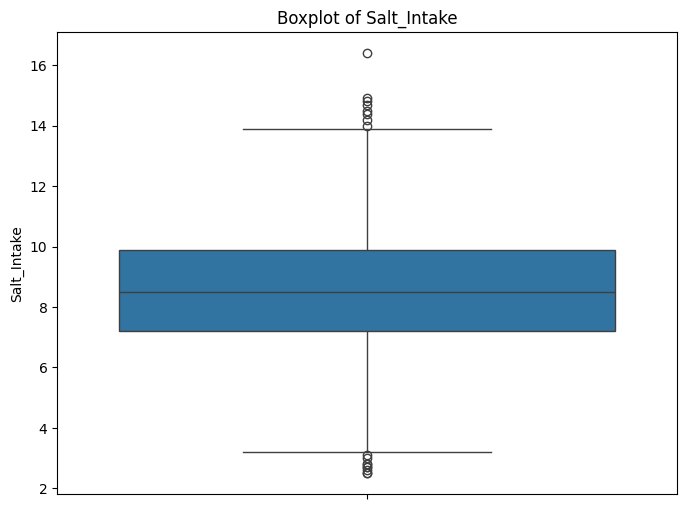

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Salt_Intake'])
plt.title('Boxplot of Salt_Intake')
plt.ylabel('Salt_Intake')
plt.show()

Dari gambar diatas, dapat disimpulkan bahwa:
1. Distribusi nilai Salt_Intake terfokus pada median yang berada pada rentang sedang, menunjukkan bahwa banyak responden memiliki tingkat konsumsi garam yang cenderung moderat.

2. Rentang interkuartil (IQR) terlihat cukup sempit, menunjukkan bahwa sebagian besar data Salt_Intake tidak terlalu jauh dari nilai tengah dan cenderung seragam.

3. Terdapat outlier di sisi bawah (nilai yang sangat rendah) dan sisi atas (nilai yang sangat tinggi), yang menunjukkan bahwa ada individu dengan konsumsi garam yang sangat rendah atau sangat tinggi dibandingkan dengan sebagian besar populasi.

4. Outlier pada nilai tinggi menunjukkan kemungkinan adanya pola konsumsi garam yang berlebihan pada sebagian kecil individu, yang mungkin berkaitan dengan meningkatnya risiko kesehatan seperti hipertensi.

Secara keseluruhan, distribusi Salt_Intake relatif stabil dengan sedikit nilai ekstrem.

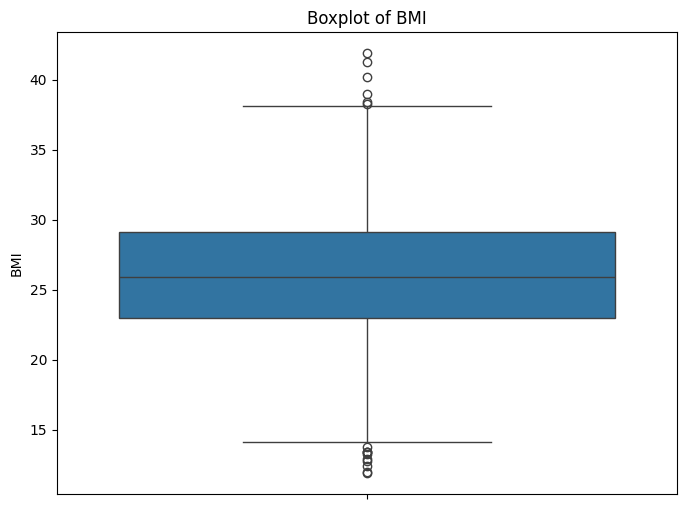

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['BMI'])
plt.title('Boxplot of BMI')
plt.ylabel('BMI')
plt.show()

Dari gambar diatas, dapat disimnulkan bahwa:
1. Nilai distribusi BMI terfokus di sekitar nilai tengah, dengan median berada pada tingkat menengah, menunjukkan bahwa sebagian besar peserta berada dalam rentang indeks massa tubuh yang tergolong normal atau sedikit lebih tinggi.

2. Rentang interkuartil (IQR) memperlihatkan variasi yang cukup seimbang, yang berarti sebagian besar data BMI tidak terlalu menyimpang dari nilai pusat distribusi.

3. Ada outlier di bagian bawah distribusi, menandakan adanya individu dengan nilai BMI yang sangat rendah, yang mungkin mencerminkan masalah berat badan yang kurang.

4. Di sisi lain, terdapat juga outlier di bagian atas distribusi, menunjukkan bahwa ada individu dengan nilai BMI yang sangat tinggi, yang bisa menunjukkan kondisi obesitas pada sebagian kecil dari responden.

 Secara umum, distribusi BMI cukup konsisten dengan adanya sedikit nilai ekstrem di kedua ujungnya.

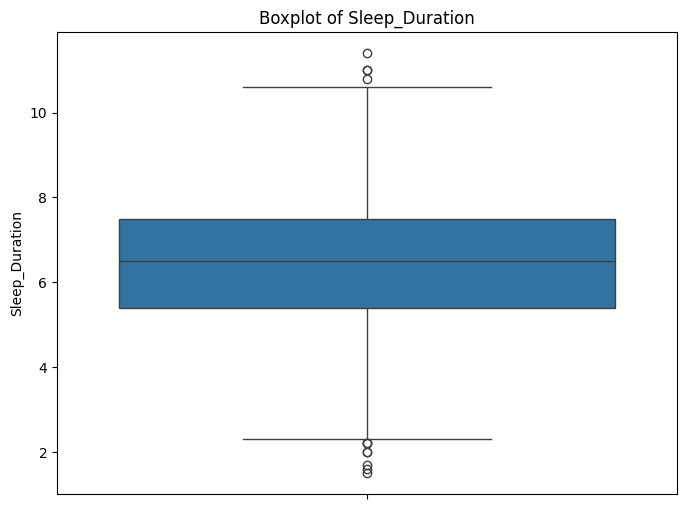

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Sleep_Duration'])
plt.title('Boxplot of Sleep_Duration')
plt.ylabel('Sleep_Duration')
plt.show()

Dari gambar diatas, dapat disimpulkan bahwa:

1. Distribusi nilai Sleep_Duration terfokus di sekitar nilai tengah, dengan median terletak di titik tengah, yang mengindikasikan bahwa kebanyakan partisipan memiliki durasi tidur yang cukup normal.

2. Rentang interkuartil (IQR) menunjukkan variasi yang terbilang sedang, yang berarti mayoritas data durasi tidur tidak menyebar jauh dari nilai tengah distribusi.

3. Terdapat outlier di bagian bawah distribusi, yang menunjukkan adanya individu dengan durasi tidur yang sangat pendek, mungkin mencerminkan gangguan dalam pola tidur atau kondisi kesehatan tertentu.

4. Ada juga outlier di bagian atas distribusi, yang menunjukkan ada individu dengan durasi tidur yang jauh lebih panjang dibandingkan dengan kebanyakan responden.

Secara keseluruhan, distribusi Sleep_Duration cukup stabil dengan sejumlah kecil nilai ekstrem di masing-masing sisi.

#**Eksplorasi Data (EDA)**

##**Comparison**

Aktivitas:
Membandingkan rata-rata usia (Age) pada setiap kategori obat (Medication).

Tujuan:
Mengidentifikasi perbedaan karakteristik usia pasien berdasarkan jenis Medication yang digunakan serta membandingkan kelompok usia antar kategori obat secara langsung.

Visualisasi:
Bar Chart (Grafik Batang).

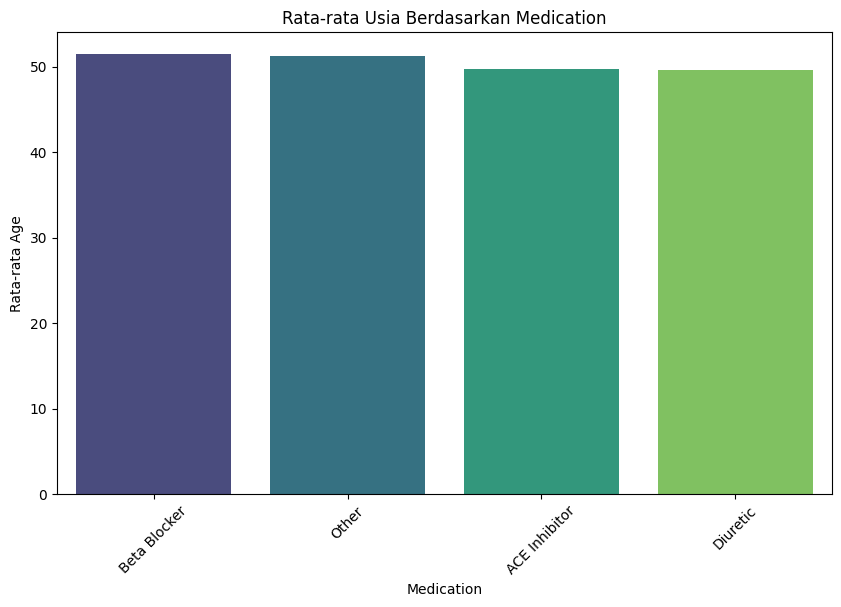

In [ ]:
age_by_medication = df.groupby('Medication')['Age'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=age_by_medication.index, y=age_by_medication.values, hue=age_by_medication.index, palette='viridis')

plt.title('Rata-rata Usia Berdasarkan Medication')
plt.xlabel('Medication')
plt.ylabel('Rata-rata Age')
plt.xticks(rotation=45)
plt.show()

Dari diagram batang diatas, dapat disimpulkan bahwa:
1. Rata-rata usia pasien untuk masing-masing kategori Medication berada pada kisaran yang cukup dekat, yaitu di akhir 40-an hingga awal 50-an tahun, yang menunjukkan bahwa tipe-tipe obat tersebut tidak dikuasai oleh kelompok usia yang sangat bervariasi.

2. Kategori Medication seperti Beta Blocker dan Lainnya menunjukkan rata-rata usia yang sedikit lebih tinggi dibandingkan dengan kategori ACE Inhibitor dan Diuretic, yang menunjukkan bahwa obat-obat ini cenderung lebih banyak dipakai oleh pasien yang lebih senior.

3. Perbedaan rata-rata usia antar kategori Medication tampak tidak signifikan, sehingga usia tidak menjadi faktor utama dalam pemilihan jenis obat dalam dataset ini.

4. Pola ini menandakan bahwa berbagai jenis Medication digunakan oleh kelompok usia yang cukup serupa, sehingga kemungkinan faktor lain seperti kondisi kesehatan, tingkatan keparahan hipertensi, atau aspek gaya hidup lebih berpengaruh dalam pemilihan jenis obat dibandingkan hanya berdasarkan usia.

##**Composition**

Aktivitas:
Menganalisis komposisi penggunaan Medication berdasarkan proporsi jumlah pasien pada setiap kategori obat.

Tujuan:
Mengidentifikasi jenis Medication yang paling dominan digunakan.

Visualisasi:
Pie Chart (Diagram Lingkaran).

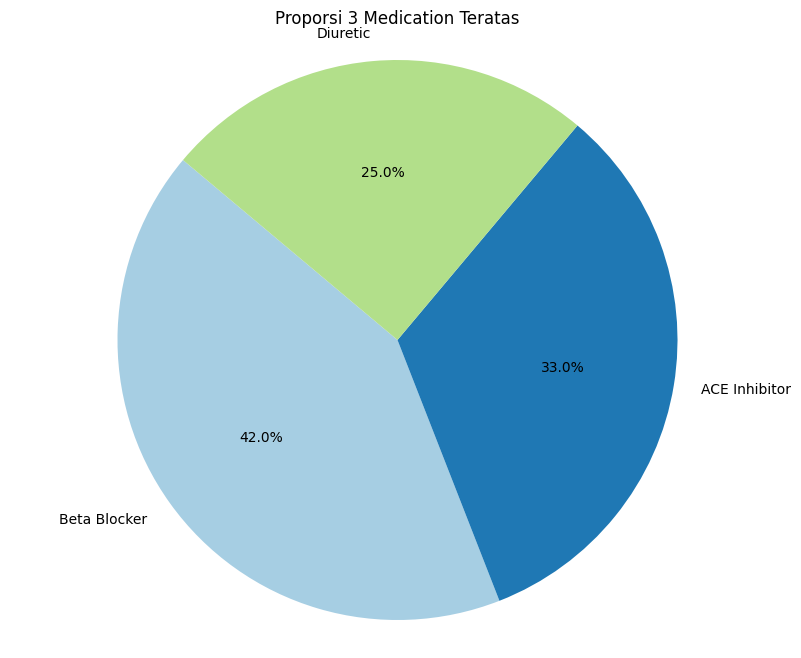

In [ ]:
medication_count = df.groupby('Medication').size().sort_values(ascending=False)
medication_top3 = medication_count.head(3)

plt.figure(figsize=(10, 8))
medication_top3.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors
)

plt.title('Proporsi 3 Medication Teratas')
plt.ylabel('')
plt.axis('equal')
plt.show()

Dari diagram pie diatas, dapat disimpulkan bahwa:
1. Rincian penggunaan medication menunjukkan bahwa Beta Blocker adalah jenis obat yang paling menonjol dengan porsi kira-kira 42%, menjadikannya opsi yang paling sering dipilih dalam kumpulan data.

2. ACE Inhibitor berada di urutan kedua dengan porsi sekitar 33%, menunjukkan bahwa obat ini juga cukup luas digunakan namun masih di bawah Beta Blocker dalam hal tingkat penggunaan.

3. Diuretic memiliki porsi terendah di antara tiga jenis Medication teratas, yaitu sekitar 25%, sehingga relatif lebih sedikit digunakan dibandingkan dengan dua jenis obat lainnya.

4. Pola distribusi ini mengindikasikan bahwa pemakaian obat tidak seimbang, dengan lebih banyak pasien memilih Beta Blocker dan ACE Inhibitor daripada Diuretic.

5. Struktur komposisi tersebut menunjukkan bahwa pengobatan hipertensi dalam data lebih terfokus pada dua jenis obat utama, sementara Diuretic berfungsi sebagai opsi tambahan yang dipakai oleh sejumlah pasien.

##**Distribution**

Aktivitas:
Menganalisis penyebaran nilai Body Mass Index (BMI) pada data pasien.

Tujuan:
Melihat apakah mayoritas nilai BMI berada pada rentang rendah, sedang, atau tinggi serta mendeteksi adanya kecondongan distribusi (skewness) dalam data BMI.

Visualisasi:
Histogram.

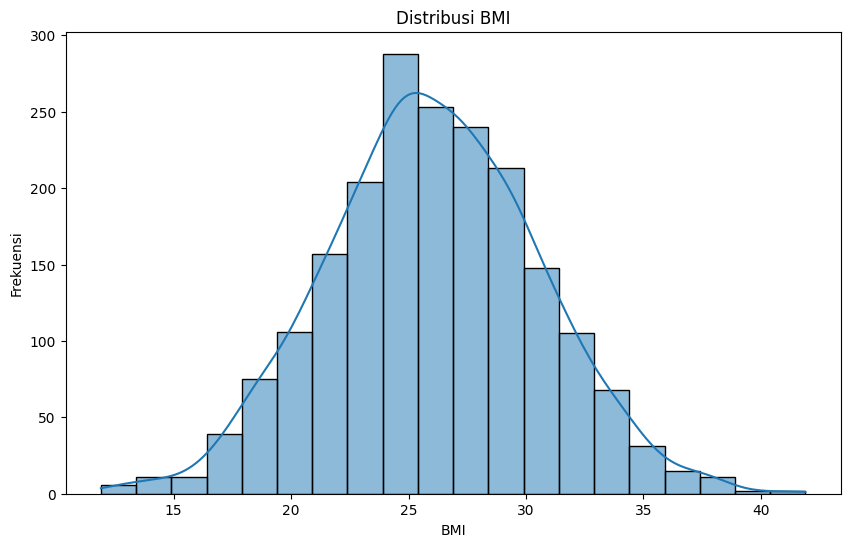

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['BMI'], bins=20, kde=True)

plt.title('Distribusi BMI')
plt.xlabel('BMI')
plt.ylabel('Frekuensi')

plt.show()

Dari Histogram diatas, dapat disimpulkan bahwa:
1. Pola distribusi nilai BMI menyerupai bentuk distribusi normal (seperti lonceng), dimana sebagian besar data terpusat di sekitar nilai rata-rata.

2. Titik tertinggi distribusi terletak pada rentang BMI sekitar pertengahan dua puluhan, yang mengindikasikan bahwa sebagian besar peserta berada dalam kategori berat badan normal hingga sedikit berlebihan.

3. Penyebaran data tampil relatif seimbang, walaupun ada ekor distribusi di kedua sisi yang menunjukkan terdapat individu dengan BMI rendah dan tinggi.

4. Frekuensi data berkurang secara bertahap seiring dengan nilai BMI yang semakin rendah atau tinggi, menandakan bahwa jumlah kasus dengan BMI ekstrem cukup sedikit jika dibandingkan dengan kelompok mayoritas.

Secara keseluruhan, distribusi BMI menunjukkan variasi yang cukup sederhana dalam populasi, dengan konsentrasi paling besar pada rentang BMI yang sedang.

##**Relationship**

Aktivitas:
Menganalisis hubungan (korelasi) antara variabel numerik, yaitu Age, BMI, Stress_Score, dan Sleep_Duration.

Tujuan:
Mengetahui apakah terdapat hubungan yang signifikan antara faktor usia, indeks massa tubuh, tingkat stres, dan durasi tidur, serta mengidentifikasi variabel mana yang memiliki keterkaitan paling kuat dalam konteks kondisi kesehatan pasien.

Visualisasi:
Heatmap

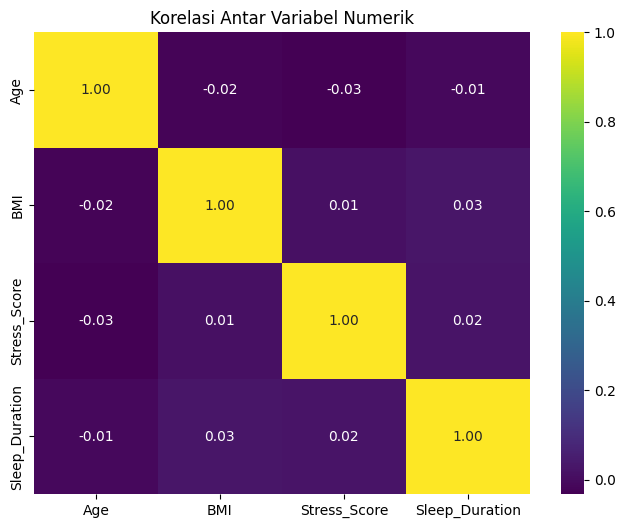

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    data=df[['Age', 'BMI', 'Stress_Score', 'Sleep_Duration']].corr(),
    annot=True,
    cmap='viridis',
    fmt='.2f')
plt.title('Korelasi Antar Variabel Numerik')
plt.show()

Dari heatmap diatas, dapat disimpulkan bahwa:
1. Hubungan antara variabel numerik seperti (Age, BMI, Stress_Score, dan Sleep_Duration) menunjukkan nilai yang sangat kecil dan mendekati nol, yang menunjukkan bahwa adanya hubungan linear di antara variabel-variabel tersebut sangat lemah.

2. Age memiliki hubungan negatif yang sangat rendah terhadap BMI, Stress_Score, dan Sleep_Duration, sehingga perubahan usia tidak memiliki dampak yang signifikan terhadap ketiga variabel ini dalam data yang ada.

3. BMI memperlihatkan keterkaitan positif yang sangat kecil dengan Stress_Score dan Sleep_Duration, yang menunjukkan bahwa peningkatan BMI hanya memiliki hubungan yang sangat minim terhadap tingkat stres dan waktu tidur.

4. Stress_Score dan Sleep_Duration juga menunjukkan hubungan positif yang sangat lemah, yang menunjukkan bahwa tingkat stres dan waktu tidur hampir tidak memiliki hubungan linear yang signifikan.

Secara keseluruhan, hasil analisis korelasi ini menunjukkan bahwa variabel-variabel numerik dalam dataset cenderung berdiri sendiri dan tidak saling berpengaruh dengan kuat, sehingga hubungan antara variabel kemungkinan bersifat kompleks atau dipengaruhi oleh faktor lain yang tidak dianalisis.

# **Data Preparation**

Pada tahap ini akan dilakukan penanganan data mulai dari pembersihann data agar data yang dimiliki lebih siap di analisis, lalu penambahan data agar memudahkan dalam pengambilan keputusan analisis dan penghapusan data yang tidak perlu untuk efisiensi proses analisis. Hal ini bertujuan untuk membersihkan data dari data yang tidak sesuai dan memastikan data memiliki kualitas yang baik.

## **Data Cleaning**

Tahapan ini berfungsi untuk membersihkan data dengan cara menghapus atau memodifikasi data yang tidak lengkap, data yang tidak konsisten, data yang terduplikasi dan data yang memiliki nilai ekstrem. Hal ini bertujuan untuk mengolah data agar berkualitas dan memiliki hasil analisis yang akurat.

### **Data Type**

Data type adalah pengelompokan data berdasarkan nilai atau karakteristik tertentu. Pada tahap ini akan dilakukan pemeriksaan terhadap tipe data apakah sudah sesuai dengan nilainya atau tidak. Penetuan tipe data ini sangat penting karena memengaruhi proses pengolahan. Metode yang digunakan untuk menangani tipe data yang tidak sesuai dengan nilai adalah dengan penyesuaian.

In [ ]:
df.dtypes

,0
Age,int64
Salt_Intake,float64
Stress_Score,int64
BP_History,object
Sleep_Duration,float64
BMI,float64
Medication,object
Family_History,object
Exercise_Level,object
Smoking_Status,object


Terlihat dari pengecekan tipe data tersebut dapat disimpulkan bahwa antara tipe data dan nilai datanya telah sesuai atau tidak ada tipe data yang salah. Contohnya seperti data Age atau umur yang bertipe data integer yang nilai dari data tersebut berupa angka dan data Exercise Level atau level aktivitas fisik yang bertipe data object karena emang nilainya berupa kata seperti low dan high.

### **Inconsistent Values**

Pada tahap ini akan dilakukan penyelerasan format data yang sebelumnya tidak konsisten menjadi konsisten agar memudahkan kita dalam mengolah dan mengambil keputusan. Metode yang digunakan dalam tahap ini adalah parsing yang berarti penyamaan format agar lebih terstruktur.

Terlihat dari pengecekan data pada bagian data understanding, sub verifikasi kualitas data dan poin Inconsistent Values dapat disimpulkan bahwa dataset yang saya miliki ini memiliki nilai yang konsisten atau tidak terdapat inkonsisten nilai pada dataset ini sehingga mengakibatkan tidak perlu adanya penanganan atau pembersihan pada bagian inconsistent values.

### **Missing Values**

Tahapan ini dilakukan untuk mencari tau data yang hilang, lalu ditangani dengan cara dihapus atau diimputasi. Missing values dapat memengaruhi kualitas data sehingga diperlukan penanganan agar data yang dimiliki memiliki kualitas yang baik untuk dianalisis. Kedua metode tersebut digunakan tergantung pada kondisi data tersebut apakah dihapus atau diimputasi.

In [ ]:
df['Medication'] = df['Medication'].fillna(df['Medication'].mode()[0])

Metode yang digunakan dalam menangani missing values pada data medication adalah dengan modus karena tipe data nilai yang hilang merupakan object. Metode ini cocok digunakan untuk menangani missing value yang memiliki tipe data non numerik, seperti jenis obat.

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Age,0.0
Salt_Intake,0.0
Stress_Score,0.0
BP_History,0.0
Sleep_Duration,0.0
BMI,0.0
Medication,0.0
Family_History,0.0
Exercise_Level,0.0
Smoking_Status,0.0


Setelah dilakukan penanganan terhadap missing value pada data Medication, dapat dilihat bahwa persentase missing valuenya telah hilang.

### **Duplicated Values**

Tahapan ini dilakukan untuk menangani data yang memiliki duplikasi. Duplikasi data dapat terjadi akibat kesalahan proses pencatatan, penggabungan data dari berbagai sumber, atau kesalahan sistem saat penginputan. Penanganannya adalah dengan dihapus data yg terduplikasi.

Terlihat dari pengecekan data pada bagian data understanding, sub verifikasi kualitas data dan poin Duplicated Values dapat disimpulkan bahwa dataset ini tidak memiliki nilai yang terduplikasi sehingga mengakibatkan tidak perlu adanya penanganan atau pembersihan pada bagian Duplicated values.

### **Outliers**

Tahapan ini dilakukan untuk menangani data yang memiliki nilai ekstrem atau nilai yang tidak biasa dibanding nilai lainnya. Hal ini dapat terjadi karena adanya kesalahan dalam penginputan ataupun kondisi tertentu yang membuat nilainya ekstrem. Hal ini dapat ditangani dengan metode hapus atau bisa diabaikan. Namun bisa juga menggunakan metode capping dan flooring.

Terlihat dari pengecekan data pada bagian data understanding, sub verifikasi kualitas data dan poin Outliers dapat disimpulkan bahwa dataset ini memiliki nilai ekstrem di kolom Salt_Intake, Sleep_Duration, dan BMI. Namun, karena persentasenya kecil dan data tersebut merupakat data kondisi seseorang jadi dapat dipastikan bahwa data bersifat variatif dan memiliki nilai yang berbeda dari nilai rata-rata individu lainnya.

## **Contruct Data**

Tahapan ini merupakan tahapan penambahan pada data baru yang bertujuan untuk memberikan pemahaman lebih baik pada dataset kita dan mempercepat proses pengambilan keputusan. Metode yang digunakan untuk menambah data baru adalah dengan memanipulasi data.

In [ ]:
def bmi_category(BMI):
    if BMI > 18.5:
        return 'Underweight'
    elif BMI < 25:
        return 'Normal'
    elif BMI < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_level'] = df['BMI'].apply(bmi_category)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   object 
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1985 non-null   object 
 7   Family_History    1985 non-null   object 
 8   Exercise_Level    1985 non-null   object 
 9   Smoking_Status    1985 non-null   object 
 10  Has_Hypertension  1985 non-null   object 
 11  bmi_level         1985 non-null   object 
dtypes: float64(3), int64(2), object(7)
memory usage: 186.2+ KB


Pada tahap ini, saya menambahkan kolom bmi_level yang berguna untuk memudahkan analisis dari BMI atau body mass index yang merupakan perbedaan antara berat badan dan tinggi badan. Kolom ini memiliki tipe data berupa object dengan keterangaan Underweight, Normal, Overweight dan obese, sehingga memudahkan dalam mengidentifikasi kondisi tubuh individu.

## **Data Reduction**

Tahapan ini merupakan tahapan dimana data yang tidak relevan ataupun kurang penting dapat dihapus tetapi tetap menjaga data yang memiliki informasi penting. Data reduction dilakukan agar struktur data menjadi lebih ringkas tanpa menghilangkan makna dan pola utama yang terkandung di dalamnya yang membuat proses pengolahan data dapat lebih efisien.

Dilihat dari dataset yang saya gunakan, saya rasa tidak perlu adanya pengurangan terhadap kolom karena semua kolom pada dataset yang saya miliki mempunyai peran penting yang saling berhubungan untuk hasil analisis. Jadi saya rasa tidak perlu adanya pengurangan terhadap kolom pada dataset yang saya gunakan. Selain itu, setiap kolom dalam dataset merepresentasikan variabel yang berkaitan langsung dengan kondisi individu, seperti riwayat merokok, indikator kesehatan, serta informasi pendukung lainnya yang saling melengkapi. Penghapusan salah satu kolom berpotensi menghilangkan informasi penting yang dibutuhkan untuk memahami pola hubungan antarvariabel secara menyeluruh, khususnya dalam analisis kondisi kesehatan dan faktor risikonya. Oleh karena itu, seluruh kolom dipertahankan agar hasil analisis yang diperoleh tetap komprehensif, akurat, dan merepresentasikan kondisi data secara utuh.

# **Matplotlib dan Seaborn**

Pada Checkpoint ke 4 ini, kita akan mengerjakan matplotlib dan seaborn. Matplotlib adalah library Python yang digunakan untuk membuat berbagai jenis visualisasi data seperti grafik garis, batang, dan histogram. Sedangkan, seaborn adalah library visualisasi data yang dibangun di atas Matplotlib. Seaborn memudahkan pembuatan grafik statistik dengan tampilan yang lebih menarik dan informatif, seperti heatmap dan boxplot.

## **Bar Chart**

Bar Chart atau Diagram Batang adalah alat visualisasi yang menggunakan batang persegi panjang untuk menunjukkan perbandingan antara kategori-kategori yang berbeda. Pada BarChart dibawah saya memilih SeaBorn untuk alat visualisasi saya karena lebih gampang dalam memodifikasi warna. Data yang saya gunakan untuk dijadikan visualisasi BarChart adalah daya perbandingan Smoking_Status dengan Has_Hypertension, hal ini dilakukan untuk melihat seberpengaruh apa merokok dalam hipertensi.

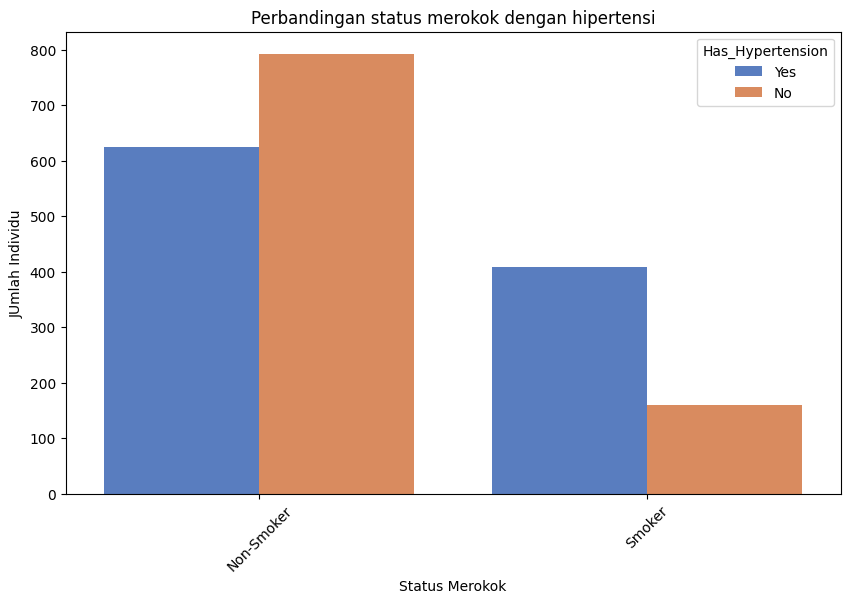

In [15]:
# Bar Chart (Seaborn)
status_merokok = df['Smoking_Status'].value_counts().head(5).sort_values(ascending=False) # head() jumlah yang mau ditampilkan & Urutan
data_filter = df[df['Smoking_Status'].isin(status_merokok.index)]

plt.figure(figsize=(10, 6)) # Ukuran
sns.countplot(x='Smoking_Status', data=data_filter, hue="Has_Hypertension", palette='muted', order=status_merokok.index) # palette (warna)
plt.title('Perbandingan status merokok dengan hipertensi') # Judul
plt.xlabel('Status Merokok') # Keterangan X
plt.ylabel('JUmlah Individu') # Keterangan Y
plt.xticks(rotation=45)
plt.show()

Dari Bar Chart diatas, dapat disimpulkan bahwa insight yang didapat adalah
1. Persentase penderita hipertensi pada perokok: Dapat dilihat pada kelompok smoker, individu yang memiliki hipertensi (Batang Biry) jauh lebih tinggi daripada yang tidak memiliki hipertensi(Batang Oren). Perbandingannya terlihat kontras, mendekati 2:1.
2. Kondisi Non-Perokok: Dapat terlihat pada diagram batang kalau kondisi non-perokok justru sebaliknya dibanding yang perokok, mayoritas individu justru tidak memiliki hipertensi. Jumlah mereka yang sehat secara tekanan darah lebih besar daripada yang terkena hipertensi.
3. Risiko: Secara visual, peluang seorang perokok terkena hipertensi jauh lebih besar daripada non-perokok. Ini menunjukkan adanya hubungan positif yang kuat antara kebiasaan merokok dengan risiko tekanan darah tinggi.

Dari insight yang didapat, maka action yang didapat adalahh:
1. Pengujian: Melakukan uji kesehatan untuk membuktikan apakah hubungan merokok dan hipertensi ini beneran signifikan atau hanya kebetulan di data ini.
2. Penghitungan: Mengingat jumlah sampel Non-Smoker lebih banyak, sebaiknya hitung persentase/rasio hipertensi di dalam masing-masing grup agar perbandingannya lebih adil.

## **Pie Chart**

Pie Chart atau Diagram Lingkaran adalah salah satu jenis visualisasi data yang menampilkan informasi dalam bentuk irisan lingkaran. Setiap irisan mewakili proporsi atau persentase dari keseluruhan data. Pada Pie Chart ini, visualisasi yang digunakan adalah Matplotlib. Data yang saya gunakan dalam Pie Chart dibawah adalah Has_Hypertension dan Familt_History yaitu untuk mengetahui perbandingan riwayat keluarga terhadap hipertensi.

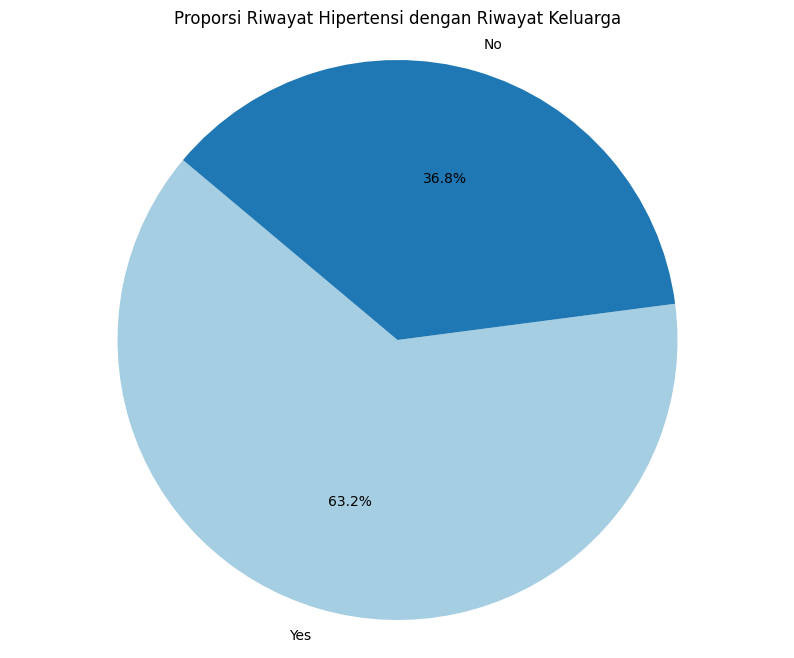

In [ ]:
# Pie Chart (Matplotlib)
family_hypertension = df[df['Has_Hypertension'] == 'Yes']['Family_History'].value_counts()

plt.figure(figsize=(10, 8)) # Ukuran
family_hypertension.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)

plt.title('Proporsi Riwayat Hipertensi dengan Riwayat Keluarga') # Judul
plt.ylabel('') # Menghilangkan label Y
plt.axis('equal')

plt.show()

Setelah dianalisis dapat disimpulkan bahwa insight yang didapat adalah:
1. Dominasi Faktor Keluarga: Berdasarkan data, sebesar 63,2% individu dalam dataset ini memiliki riwayat hipertensi yang terkait dengan riwayat keluarga. Ini menunjukkan bahwa faktor genetik atau lingkungan keluarga cukup memengaruhi hipertensi.
2. Kelompok No: 36,8% individu tidak memiliki riwayat keluarga namun tetap memiliki hipertensi.

Dari insight  yang didapat, action atau tindakan yang dapat dilakukan adalah:
1. Memberikan penyuluhan kesehatan khususnya bagi masyarakat yang memiliki riwayat keluarga hipertensi agar lebih waspada dan menjaga gaya hidup sehat.
2. Melakukan edukasi pola hidup sehat kepada masyarakat, seperti mengurangi konsumsi garam, rutin berolahraga, dan menjaga berat badan.


## **Line Chart**

Line Chart atau Grafik Garis adalah jenis visualisasi data yang menghubungkan serangkaian titik data dengan garis lurus yang biasa digunakan untuk melihat data berdasar waktu. Pada chart ini saya menggunakan dataset Age dengan Has_Hypertension yang bertujuan untuk melihat data hipertensi berdasar umur. Pada Line Chart ini saya menggunakan visualisasi Matplotlib.

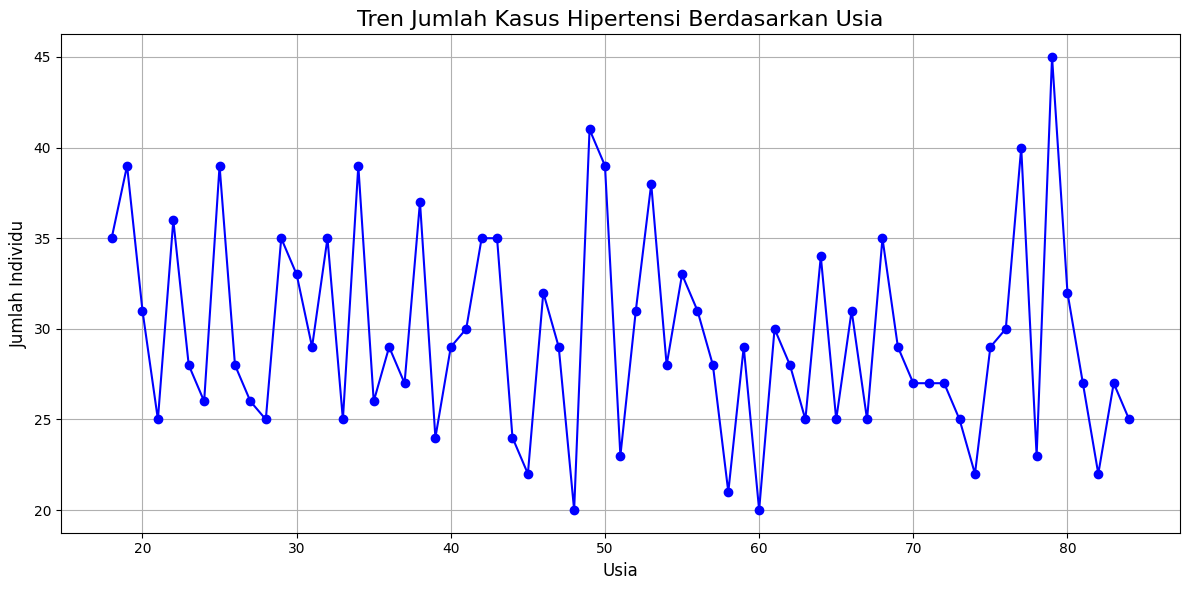

In [22]:
# Line Chart (Matplotlib) Berdasarkan Usia

age_hypertension = df.groupby('Age')['Has_Hypertension'].count()

plt.figure(figsize=(12,6)) # Ukuran
plt.plot(age_hypertension.index, age_hypertension.values, marker='o', color='blue')

plt.title('Tren Jumlah Kasus Hipertensi Berdasarkan Usia', fontsize=16) # Judul
plt.xlabel('Usia', fontsize=12) # Keterangan X
plt.ylabel('Jumlah Individu', fontsize=12) # Keterangan Y

plt.grid(True)
plt.tight_layout()
plt.show()

Setelah dilakukan analisis pada linechart diatas dapat disimpulkan bahwa insight yang didapat adalah:
1. Garis yang naik turun: Grafik ini menunjukkan bahwa kasus hipertensi tidak naik setiap umur yang lebih tua ataupun sebaliknya, melainkan bergerak naik turun di hampir semua kelompok umur.
2.  Usia bukan jadi penentu: Bisa dilihat pada grafik, rentang umur 20-30 tahun bahkan memiliki grafik yang cukup tinggi yang membuktikan hipertensi bukan penyakit orang tua.
3. Lonjakan kasus: Terlihat pada grafik, pada usia 49 dan 79 terdapat titik yang menunjukkan lonjakan kasus hipertensi pada umur terseebut. Ini menandakan ada bahaya lebih besar pada usia tersebut.

Setelah didapatkan insight, maka action yang dapat dilakukan adalah:
1. Jangan mengandalkan usia: Cek rutin tensi karena hipertensi tidak memandang usia. Dilihat dari grafik diatas rentang usia yang tergolong muda sudah mengalami hipertensi.
2. Jaga pola makan: Salah satu faktor dapat terjadi dikarenakan pola makan yang buruk, seperti mengonsumsi makan atau minum yang memiliki kadar garam tinggi. Kurangi juga konsumsi kopi atau teh karena kafein dapat meningkatkan tekanan darah sesaai.
3. Edukasi: Berikan edukasi khusus terutama oada rentang usia yang memiliki lonjakan kasus, seperti usia 50an dan akhir 70an.

## **Histogram**

Histogram adalah jenis visualisasi data berupa grafik batang yang digunakan untuk menunjukkan bagaimana suatu data numerik terbagi atau tersebar. Histogram efektif digunakan untuk melihat apakah data berdistribusi normal, miring atau memiliki outlier. Jenis Histogram yang saya gunakan adalah Seaborn yang berisi data BMI. Tujuannya untuk melihat distribusi dari BMI tersebut.  

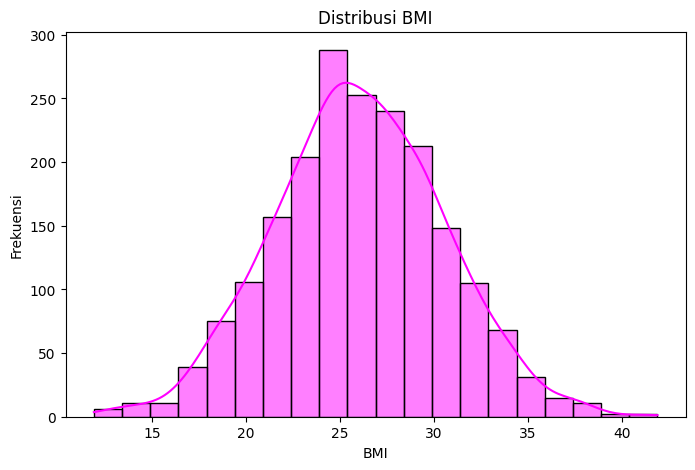

In [18]:
# Histogram (Seaborn): Distribusi BMI
plt.figure(figsize=(8, 5))
sns.histplot(df['BMI'], bins=20, kde=True, color='magenta')
plt.title('Distribusi BMI')
plt.xlabel('BMI')
plt.ylabel('Frekuensi')
plt.show()

Setelah dilakukan analisis pada histogram ini, insight yang didapat adalah:
1. Bentuk Distribusi: Bentuk grafik yang menyerupai lonceng (simetris) menunjukkan bahwa data BMI berdistribusi normal. Ini adalah tanda yang baik secara statistik karena data terpusat di sekitar nilai rata-rata.
2. Penyebaran: Data menyebar dari angka 15 hingga sekitar 40. Meskipun sebagian besar berada di rentang normal hingga overweight, terdapat populasi yang berada di bawah 18.5 (underweight) dan di atas 30 (obesitas).
3. Pusat Data (Mean/Median): Puncak kurva berada di rentang angka 25. Dalam standar klasifikasi kesehatan, angka 25 merupakan ambang batas awal untuk kategori berat badan berlebih (overweight).

Setelah didapatkan insight, maka action yang dapat dilakukan adalah:
1. Pencegahan: Karena puncak distribusi berada di angka 25, maka ini dapat menjadi penanda terhadap tim kesehatan mengenai edukasi manajemen berat badan. Hal ini bertujuan untuk mencegah mereka untuk tidak bergeser ke obesitas karena BMI 25-27 merupakan ambang batas.
2. Pengelompokkan target:
- Untuk target yang memiliki BMI dibawah 18, disarankan untuk melakukan pengecekan terkait kekurangan gizi atau metabolisme.
- Untuk yang diatas 30 diperlukan diet atau penurunan berat badan dan pengecekan kesehatan karena memiliki risiko komplikasi seperti hipertensi dan lainnya.

## **BoxPlot**

Boxplot adalah grafik yang digunakan untuk melihat distribusi dan sebaran data numerik secara ringkas. Box plot cocok digunakan untuk menganalisis sebaran data dan mendeteksi outlier. Grafik ini menampilkan median, kuartil, serta nilai ekstrem. Boxplot yang saya gunakan adalah boxplot Seaborn. Data yang saya gunakan pada boxplot adalah Stress_Score dan Exercise_Level dengan tujuan untuk mengetahui perbandingan skor stress dan instensitas latihan.

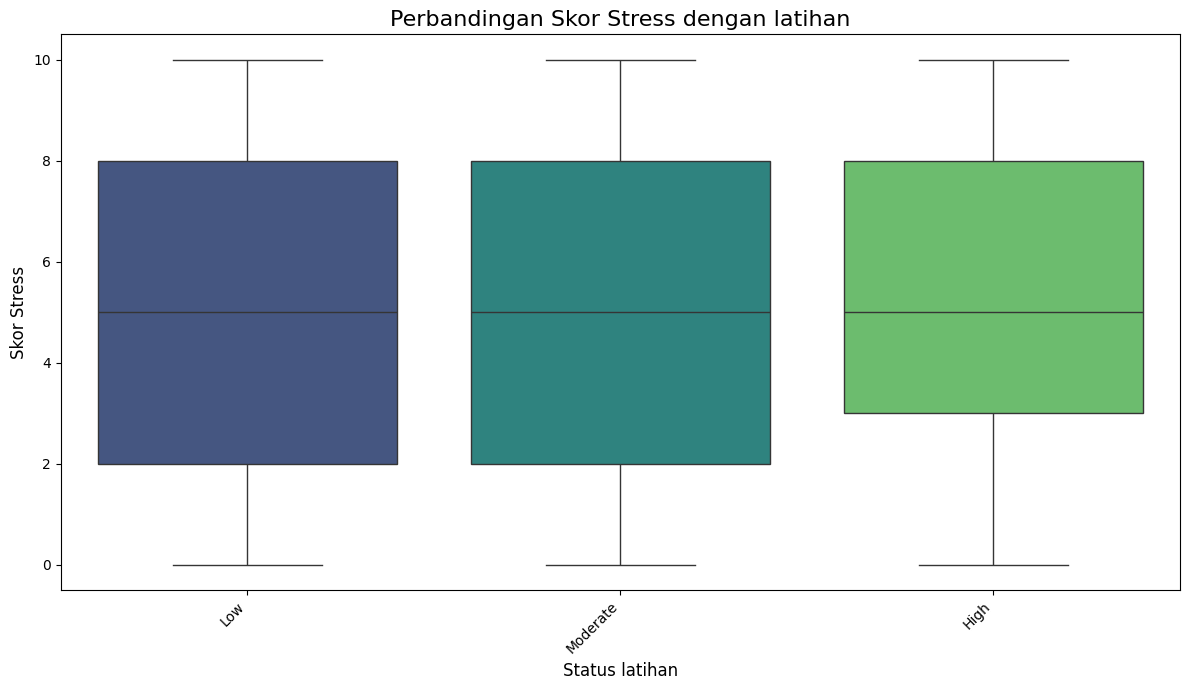

In [ ]:
status_latihan = df['Exercise_Level'].value_counts().head(5).index
data_filterred = df[df['Exercise_Level'].isin(status_latihan)]

plt.figure(figsize=(12, 7)) # Ukuran figure
sns.boxplot(x='Exercise_Level', y='Stress_Score', data=data_filterred, palette='viridis', order=status_latihan, hue='Exercise_Level', legend=False)
plt.title('Perbandingan Skor Stress dengan latihan', fontsize=16) # Judul
plt.xlabel('Status latihan', fontsize=12) # X Keterangan
plt.ylabel('Skor Stress', fontsize=12) # Y Keterangan
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Setelah dilakukan analisis pada Boxplot ini, insight yang didapat adalah:
1. Median: Skor stres pada ketiga tingkat latihan terlihat relatif sama, yaitu sekitar nilai 5.
2. Nilai stres: Rentang nilai pada setiap kategori latihan cukup mirip, sekitar 0 hingga 10, yang menunjukkan variasi tingkat stress yang hampir sama pada setiap kelompok.
3. Hal ini menunjukkan bahwa tingkat latihan tidak menunjukkan perbedaan yang signifikan terhadap skor stres.

Setelah didapatkan insight, maka action yang dapat dilakukan adalah:
1. Perlu dilakukan analisis lanjutan untuk melihat faktor lain yang mungkin lebih mempengaruhi stres, seperti kualitas tidur pekerjaan, atau pola hidup.
2. Dapat dilakukan program manajemen stres seperti olahraga rutin, relaksasi, atau meditasi untuk membantu menurunkan tingkat stres.


## **ScatterPlot**

Scatter plot adalah jenis grafik yang menggunakan titik-titik untuk Scatter plot digunakan untuk menganalisis hubungan atau
korelasi antara dua variabel numerik. Scatter Plot yang saya gunakan adalah scatter plot jenis Matplotlib. Data yang digunakan pada scatterplot ini adalah Age dan Stress_Score yang bertujuan untuk melihat korelasi antara umur dan skor stres.

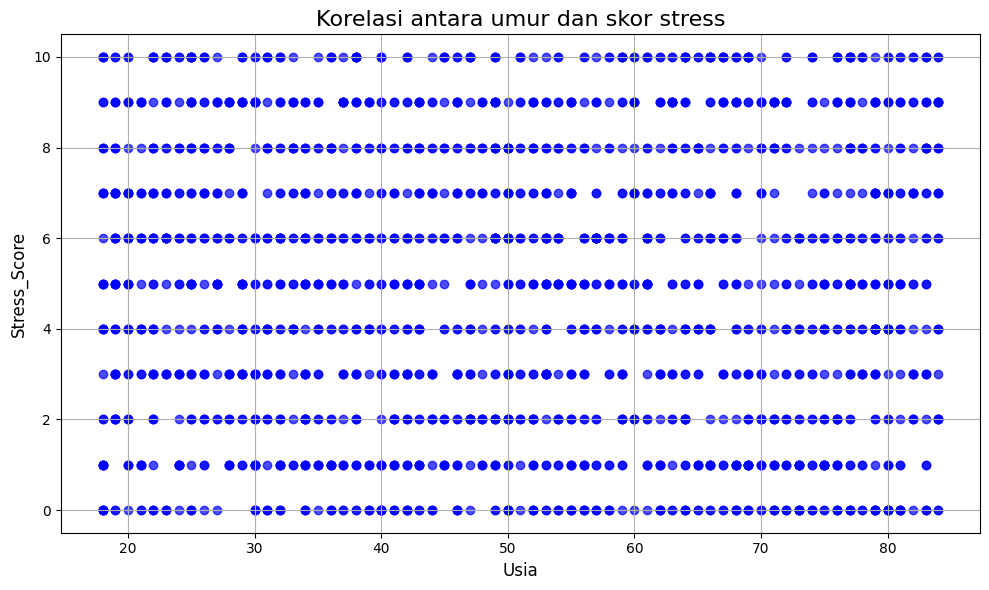

In [26]:
# ScatterPlot Matplotlib

plt.figure(figsize=(10, 6)) # Ukuran
plt.scatter(df['Age'], df['Stress_Score'], alpha=0.7, color='Blue') # Color (Warna)
plt.title('Korelasi antara umur dan skor stress', fontsize=16) # Judul
plt.xlabel('Usia', fontsize=12) # X Keterangan
plt.ylabel('Stress_Score', fontsize=12) # Y Keterangan
plt.grid(True)
plt.tight_layout()
plt.show()

Setelah dilakukan analisis pada Scatterplot ini, insight yang didapat adalah:
1. Skor stres: Dari scatter plot terlihat bahwa skor stres tersebar pada semua rentang usia, mulai dari usia muda hingga usia lanjut.
2. Pola Hubungan: Tidak terlihat pola hubungan yang jelas antara usia dan skor stres, karena pada setiap usia terdapat nilai stres yang rendah hingga tinggi.
3. Kesimpulan: Hal ini menunjukkan bahwa tingkat stres tidak hanya dipengaruhi oleh usia, tetapi kemungkinan dipengaruhi oleh faktor lain seperti pekerjaan, kondisi kesehatan, atau gaya hidup.

Setelah didapatkan insight, maka action yang dapat dilakukan adalah:
1. Program edukasi mengenai stres kepada semua kelompok usia karena stres dapat terjadi di usia berapa pun.
2. Dapat dilakukan pendekatan kesehatan mental dan gaya hidup sehat seperti olahraga rutin, manajemen waktu, dan relaksasi untuk membantu mengurangi stres.

## **Bubble Chart**

Bubble Chart atau Diagram Gelembung adalah versi tiga dimensi dari scatter plot yang berfungsi untuk menunjukkan komposisi dan perbandingan dari kategori dalam bentuk bubble atau gelembung yang berbeda dimensi. Pada Bubble Chart ini visualisasi yang digunakan adalah Seaborn. Bubble Chart ini berisi hubungan durasi tidur dan tingkat stres.

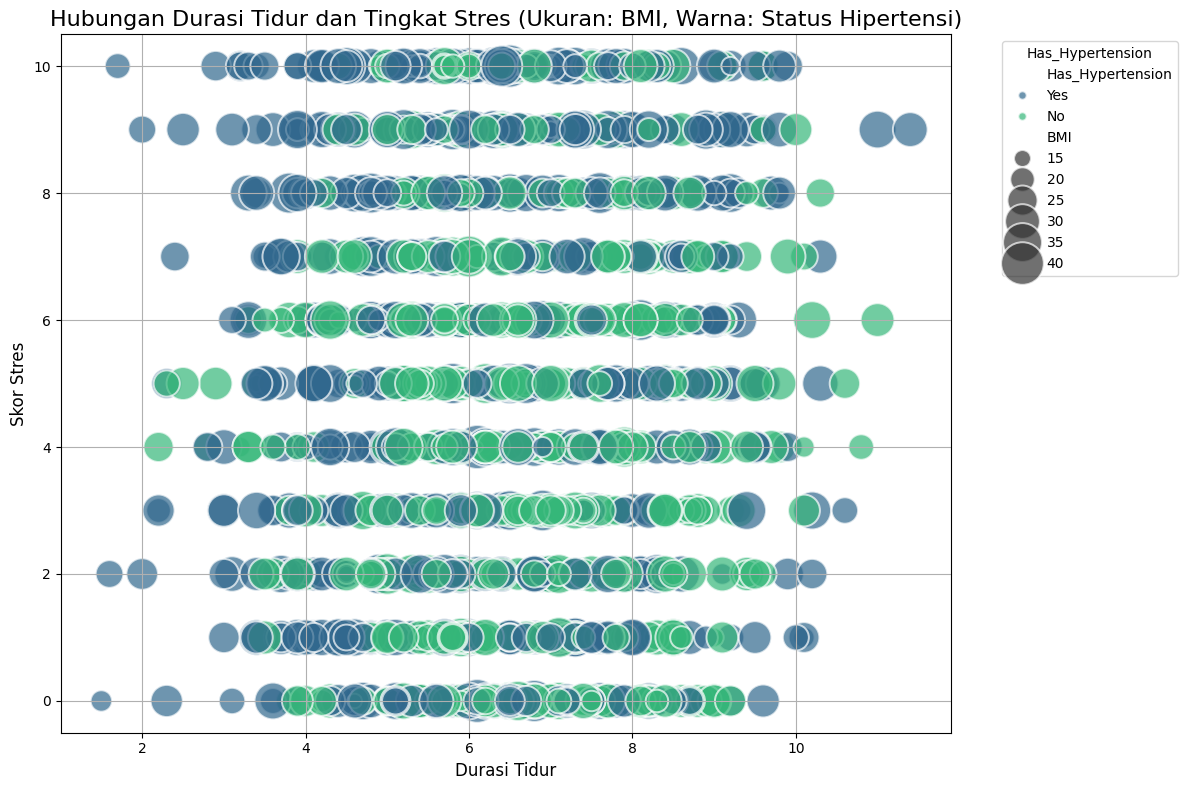

In [28]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Sleep_Duration', y='Stress_Score', size='BMI', hue='Has_Hypertension', data=df, sizes=(50, 1000), alpha=0.7, palette='viridis')
plt.title('Hubungan Durasi Tidur dan Tingkat Stres (Ukuran: BMI, Warna: Status Hipertensi)', fontsize=16)
plt.xlabel('Durasi Tidur', fontsize=12)
plt.ylabel('Skor Stres', fontsize=12)
plt.grid(True)
plt.legend(title='Has_Hypertension', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Setelah dilakukan analisis pada Bubble Chart ini, insight yang didapat adalah:
1. Durasi tidur dan stres: Data menunjukkan bahwa durasi tidur tersebar pada semua tingkat stres, sehingga tidak terlihat hubungan yang sangat kuat antara lamanya tidur dan skor stres. Durasi tidur sekitar 6–8 jam masih memiliki variasi tingkat stres dari rendah hingga tinggi.
2. BMI Tinggi: Bubble dengan ukuran besar (BMI tinggi) juga muncul pada berbagai tingkat stres, yang menunjukkan bahwa BMI tidak selalu berkaitan langsung dengan stres dalam pola yang jelas pada grafik ini.
3. Status Hipertensi: Penyebaran status hipertensi (Yes/No) terdapat di hampir semua kombinasi durasi tidur dan stres, sehingga hipertensi kemungkinan dipengaruhi oleh beberapa faktor sekaligus, bukan hanya tidur atau stres saja.

Setelah didapatkan insight, maka action yang dapat dilakukan adalah:
1. Mendorong masyarakat untuk menjaga durasi tidur yang cukup (sekitar 7–8 jam) karena tidur yang baik tetap penting bagi kesehatan.
2. Melakukan edukasi mengenai manajemen stres dan gaya hidup sehat, seperti olahraga rutin dan pola makan seimbang untuk membantu menurunkan risiko hipertensi.

## **Heatmap**

Heatmap adalah teknik visualisasi data yang menggunakan representasi warna digunakan untuk melihat pola dan perbedaan nilai melalui gradasi warna. Pada heatmap ini jenis visualisasi yang digunakan adalah Seaborn. Data yang digunakan dalam heatmap ini adalah semua data numerik dengan tujuan untuk mengetahui korelasi antara variabel numerik pada dataset Individual Hypertension Risk Prediction.

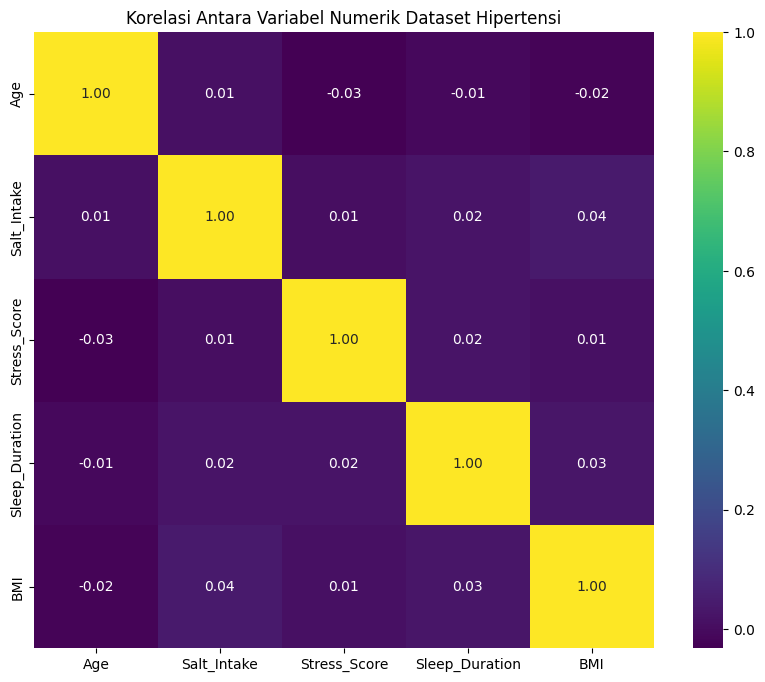

In [31]:
plt.figure(figsize=(10, 8))
sns.heatmap(data=df.corr(numeric_only=True),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi Antara Variabel Numerik Dataset Hipertensi')
plt.show()

Setelah dilakukan analisis pada Scatterplot ini, insight yang didapat adalah:
1. Korelasi antara BMI dan Age adalah Negatif lemah.
- Insight: Hubungan ini sangat lemah, yang berarti bertambahnya usia hampir tidak memberikan pengaruh yang konsisten terhadap perubahan nilai BMI dalam data ini.
- Action: Anda tidak bisa menggunakan usia sebagai prediktor untuk memperkirakan kenaikan atau penurunan berat badan pada populasi ini.

2. Korelasi antara Sleep_Duration dan Age adalah negatif lemah.
- Insight: Secara statistik, durasi tidur tidak memiliki ketergantungan yang berarti terhadap usia; pola tidur responden sangat bervariasi terlepas dari berapa pun usia mereka.
- Action: Fokuskan intervensi kesehatan tidur pada individu secara personal berdasarkan keluhan mereka, bukan berdasarkan pengelompokan usia.

3. Korelasi antara Stress_Score dan Age adalah negatif lemah.
- Insight: Nilai ini menunjukkan bahwa usia sama sekali tidak menjadi penentu utama tinggi-rendahnya skor stres seseorang.
- Action: Karena stres tersebar secara merata di semua usia, program manajemen stres harus dirancang secara inklusif untuk semua kelompok umur.

4. Korelasi antara Salt_Intake dan BMI adalah positif lemah:
- Insight: Meskipun positif, hubungan ini sangat lemah, artinya asupan garam yang tinggi tidak menunjukkan pola kenaikan BMI yang signifikan pada dataset ini.
- Action: Jangan berasumsi bahwa orang dengan berat badan lebih tinggi pasti mengonsumsi lebih banyak garam. Pola makan harus tetap dipantau secara individual.

5. Korelasi antara BMI dan Sleep_Duration adalah positif lemah.
- Insight: Angka ini sangat mendekati nol, menunjukkan bahwa durasi tidur responden hampir tidak memiliki kaitan dengan indeks massa tubuh (BMI).
- Action: Jangan menyimpulkan bahwa perubahan durasi tidur akan secara otomatis mengubah BMI seseorang dalam populasi ini.

6. Korelasi antara Salt_Intake dan Sleep Duration adalah positif lemah.
- Insight: Hubungan yang sangat lemah ini menegaskan bahwa tingkat konsumsi garam harian tidak memberikan pengaruh terhadap durasi tidur.
- Action: Dalam edukasi kesehatan, tidak perlu mengaitkan masalah gangguan tidur dengan asupan garam secara spesifik karena data tidak menunjukkan kaitan tersebut.

# **Menyimpan Dataset**

Tahapan ini dilakukan untuk menyimpan dataset yang telah melalui proses pengolahan ke dalam media penyimpanan, sehingga data tersebut dapat digunakan kembali tanpa perlu mengulang proses pengolahan dari awal.

In [32]:
df.to_csv('Individual Hypertension Risk Prediction.csv',index=False)

Pada dataset ini, saya menyimpan dengan format csv atau Comma-Separated Values yang merupakan format file untuk menyimpan data dalam bentuk tabel, di mana setiap nilai dipisahkan oleh tanda koma (,).